用地图边界范围筛选掉一些数据

In [2]:
import sys
!"{sys.executable}" -m pip install -U pip
!"{sys.executable}" -m pip install -U geopandas pyogrio shapely fiona tqdm


  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)


In [3]:
import os, time, math, subprocess
import pandas as pd
import geopandas as gpd
from tqdm.auto import tqdm

CSV0 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class.csv"
CSV1 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class.csv"
SHP  = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/3_urbanpark_research_area/urbanpark_research_area.shp"

CHUNKSIZE = 300_000

def wc_lines(path: str) -> int:
    """mac/linux 下快速统计行数（含表头），失败则返回 -1"""
    try:
        out = subprocess.check_output(["wc", "-l", path]).decode("utf-8").strip()
        return int(out.split()[0])
    except Exception:
        return -1

def load_area(shp_path: str):
    area = gpd.read_file(shp_path)
    if area.empty:
        raise ValueError(f"SHP 没有任何要素：{shp_path}")
    if area.crs is None:
        area = area.set_crs("EPSG:4326", allow_override=True)
    # 只保留 geometry，减少 join 的负担
    area = area[["geometry"]].copy()
    # （可选）修复无效几何，避免 sjoin 报错
    try:
        area["geometry"] = area.geometry.make_valid()
    except Exception:
        pass
    return area

def filter_csv(csv_path: str, area_gdf: gpd.GeoDataFrame, chunksize: int):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(csv_path)

    out_path = os.path.splitext(csv_path)[0] + "_shp_filtered.csv"
    if os.path.exists(out_path):
        os.remove(out_path)

    # 估算总 chunk 数，用于进度条（不准也没关系）
    n_lines = wc_lines(csv_path)
    total_rows = max(n_lines - 1, 0) if n_lines > 0 else -1
    total_chunks = math.ceil(total_rows / chunksize) if total_rows > 0 else None

    total_read = total_keep = total_drop = 0
    first = True
    t0 = time.time()

    # 尽量用 pyarrow 读 csv（更快），不行就回退
    read_kwargs = dict(chunksize=chunksize, low_memory=False)
    try:
        reader = pd.read_csv(csv_path, engine="pyarrow", **read_kwargs)
        engine_used = "pyarrow"
    except Exception:
        reader = pd.read_csv(csv_path, **read_kwargs)
        engine_used = "default"

    pbar = tqdm(reader, total=total_chunks, desc=os.path.basename(csv_path), unit="chunk")

    for chunk in pbar:
        n0 = len(chunk)
        total_read += n0

        if "Lng" not in chunk.columns or "Lat" not in chunk.columns:
            raise KeyError(f"{csv_path} 缺少 Lng/Lat 列。")

        chunk["Lng"] = pd.to_numeric(chunk["Lng"], errors="coerce")
        chunk["Lat"] = pd.to_numeric(chunk["Lat"], errors="coerce")
        chunk = chunk.dropna(subset=["Lng", "Lat"])
        if chunk.empty:
            continue

        pts = gpd.GeoDataFrame(
            chunk,
            geometry=gpd.points_from_xy(chunk["Lng"], chunk["Lat"]),
            crs="EPSG:4326",
        )

        # CRS 对齐到 shp
        if pts.crs != area_gdf.crs:
            pts = pts.to_crs(area_gdf.crs)

        # ✅ 核心加速：空间索引 + sjoin
        # intersects 对点来说等价于“在面内或边界上”
        joined = gpd.sjoin(pts, area_gdf, how="inner", predicate="intersects")

        kept = joined.drop(columns=["geometry", "index_right"], errors="ignore")

        kept_n = len(kept)
        drop_n = len(pts) - kept_n
        total_keep += kept_n
        total_drop += drop_n

        kept.to_csv(out_path, index=False, mode="w" if first else "a", header=first)
        first = False

        elapsed = time.time() - t0
        pbar.set_postfix({
            "engine": engine_used,
            "read": f"{total_read:,}",
            "kept": f"{total_keep:,}",
            "drop": f"{total_drop:,}",
            "min": f"{elapsed/60:.1f}",
        })

    elapsed = time.time() - t0
    print("\n----------------------------------------")
    print(f"Input : {csv_path}")
    print(f"Output: {out_path}")
    print(f"Read  : {total_read:,}")
    print(f"Kept  : {total_keep:,}")
    print(f"Dropped (out of shp): {total_drop:,}")
    print(f"Elapsed: {elapsed/60:.2f} min")

# ===== run =====
area = load_area(SHP)
print("Loaded shp:", SHP)
print("SHP CRS  :", area.crs)
print("Area features:", len(area))

filter_csv(CSV0, area, CHUNKSIZE)
filter_csv(CSV1, area, CHUNKSIZE)


/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded shp: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/3_urbanpark_research_area/urbanpark_research_area.shp
SHP CRS  : EPSG:4326
Area features: 171


data_0_with_park_class.csv: 100%|██████████| 4/4 [00:12<00:00,  3.02s/chunk, engine=default, read=902,069, kept=896,699, drop=5,370, min=0.2]



----------------------------------------
Input : /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class.csv
Output: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class_shp_filtered.csv
Read  : 902,069
Kept  : 896,699
Dropped (out of shp): 5,370
Elapsed: 0.22 min


data_1_with_park_class.csv: 100%|██████████| 4/4 [00:12<00:00,  3.06s/chunk, engine=default, read=901,911, kept=896,655, drop=5,256, min=0.2]


----------------------------------------
Input : /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class.csv
Output: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class_shp_filtered.csv
Read  : 901,911
Kept  : 896,655
Dropped (out of shp): 5,256
Elapsed: 0.20 min


Sampling data_0_with_park_class_shp_filtered.csv:   6%|▌         | 9.60M/172M [00:00<00:06, 23.3MB/s]
Sampling data_1_with_park_class_shp_filtered.csv:   3%|▎         | 4.80M/172M [00:00<00:07, 22.5MB/s]


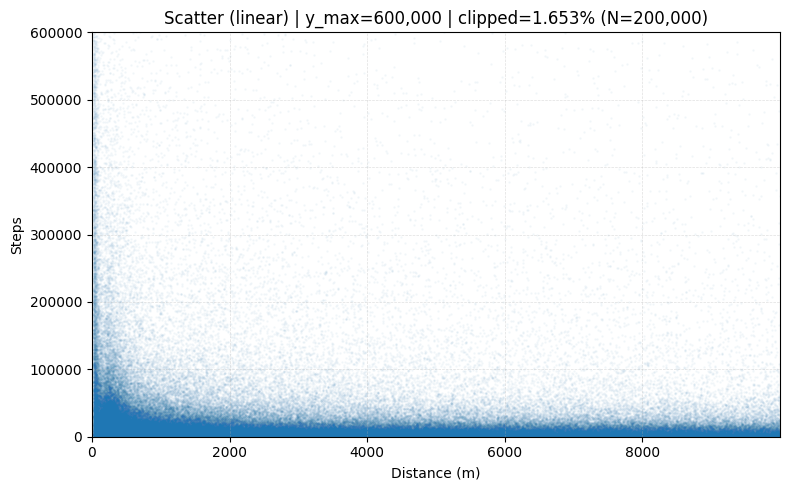

Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/src/scatter_dist_steps_ymax_600k.png
clipped% = 1.6525


In [12]:
import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

file0 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class_shp_filtered.csv"
file1 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class_shp_filtered.csv"
files = [file0, file1]

USECOLS = ["dist_straight_m", "steps"]
CHUNKSIZE = 300_000
TARGET_SAMPLE = 200_000
SEED = 123

YMAX = 600_000  # 固定显示上限（你定的）

def stream_sample_xy_linear(files, chunksize=CHUNKSIZE, target_sample=TARGET_SAMPLE, seed=SEED):
    rng = np.random.default_rng(seed)
    parts = []
    kept = 0

    for fp in files:
        total_size = os.path.getsize(fp)
        pbar = tqdm(total=total_size, desc=f"Sampling {os.path.basename(fp)}", unit="B", unit_scale=True)

        for chunk in pd.read_csv(fp, usecols=USECOLS, chunksize=chunksize):
            pbar.update(int(chunk.memory_usage(deep=True).sum()))

            chunk = chunk.dropna(subset=USECOLS)

            # 线性图：允许 dist==0，避免左侧空白；steps 仍需 >0
            chunk = chunk[(chunk["dist_straight_m"] >= 0) & (chunk["steps"] > 0)]
            if len(chunk) == 0:
                continue

            remaining = target_sample - kept
            if remaining <= 0:
                break

            frac = min(1.0, remaining / max(len(chunk), 1))
            take = chunk.sample(frac=frac, random_state=int(rng.integers(0, 1e9))) if frac < 1.0 else chunk

            parts.append(take.astype({"dist_straight_m": "float64", "steps": "float64"}))
            kept += len(take)

        pbar.close()

    df = pd.concat(parts, ignore_index=True)
    if len(df) > target_sample:
        df = df.sample(n=target_sample, random_state=seed)
    return df

# 1) 抽样用于画图
dfp = stream_sample_xy_linear(files)

# 2) clipped%
clip_ratio = float((dfp["steps"] > YMAX).mean())

# 3) 画图
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(dfp["dist_straight_m"], dfp["steps"], s=1, alpha=0.03, rasterized=True)

ax.set_xlim(0, float(dfp["dist_straight_m"].max()))
ax.set_ylim(0, YMAX)

ax.set_xlabel("Distance (m)")
ax.set_ylabel("Steps")
ax.set_title(f"Scatter (linear) | y_max={YMAX:,.0f} | clipped={clip_ratio*100:.3f}% (N={len(dfp):,})")

# 取消 y 轴的 1e6 / 偏移量显示
fmt = ScalarFormatter(useOffset=False)
fmt.set_scientific(False)
ax.yaxis.set_major_formatter(fmt)
ax.get_yaxis().get_offset_text().set_visible(False)

ax.margins(x=0, y=0)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

out_png = "scatter_dist_steps_ymax_600k.png"
plt.tight_layout()
plt.savefig(out_png, dpi=200)
plt.show()

print("Saved:", os.path.abspath(out_png))
print("clipped% =", clip_ratio * 100)


Sampling data_0_with_park_class_shp_filtered.csv:   6%|▌         | 9.60M/172M [00:00<00:08, 19.5MB/s]
Sampling data_1_with_park_class_shp_filtered.csv:   3%|▎         | 4.80M/172M [00:00<00:08, 19.9MB/s]
/var/folders/98/dxfywpxj3x5b43cvqj3dbh6m0000gn/T/ipykernel_22406/1439561556.py:240: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


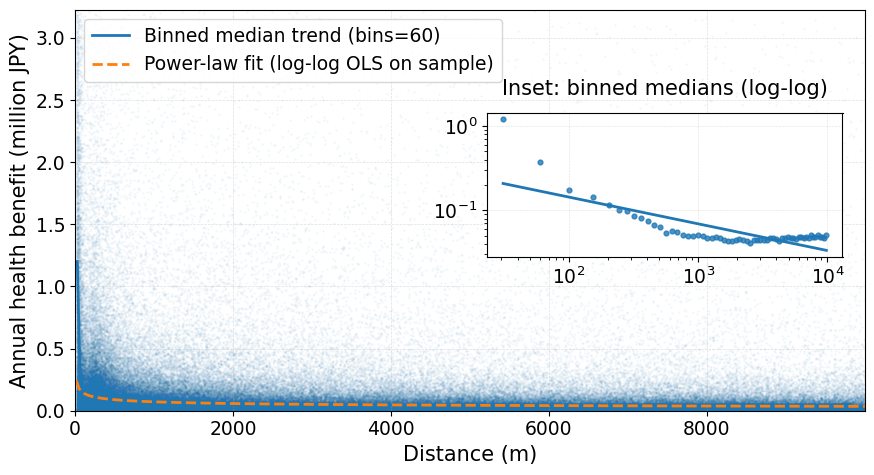

Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/src/fig1_scatter_linear_millionJPY_with_binned_trend_inset.png
clipped% = 1.6525

=== Power-law (log-log OLS) parameters (y in million JPY) ===
[Sample all points] alpha=ln(sigma)=-0.500131  sigma=0.606451  beta=-0.309199  R2(log)=0.0718
[Binned medians]    alpha=ln(sigma)=-0.483490  sigma=0.616628  beta=-0.316674  R2(log)=0.6079  bins_used=60


In [13]:
import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =========================
# 0) 文件路径
# =========================
file0 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class_shp_filtered.csv"
file1 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class_shp_filtered.csv"
files = [file0, file1]

USECOLS = ["dist_straight_m", "steps"]
CHUNKSIZE = 300_000
TARGET_SAMPLE = 200_000
SEED = 123

# =========================
# ✅ 1) 全局字号放大 1.5 倍
# =========================
TEXT_SCALE = 1.5
_base = 10  # matplotlib 默认大概 10 左右，这里显式控制更稳定
plt.rcParams.update({
    "font.size": _base * TEXT_SCALE,
    "axes.titlesize": _base * TEXT_SCALE,
    "axes.labelsize": _base * TEXT_SCALE,
    "xtick.labelsize": (_base - 1) * TEXT_SCALE,
    "ytick.labelsize": (_base - 1) * TEXT_SCALE,
    "legend.fontsize": (_base - 1) * TEXT_SCALE,
})

# =========================
# steps -> money (JPY) -> million JPY
# =========================
JPY_PER_STEP = 0.04
POP_SCALE = 134.38
MONEY_MULT = JPY_PER_STEP * POP_SCALE          # JPY/step
MONEY_UNIT = 1_000_000.0                       # 1e6 JPY = 1 million JPY

YMAX_STEPS = 600_000
YMAX = (YMAX_STEPS * MONEY_MULT) / MONEY_UNIT  # y_max（单位：百万日元）

# ====== 分箱趋势线参数 ======
N_BINS = 60
MIN_BIN_N = 200

def stream_sample_xy_linear(files, chunksize=CHUNKSIZE, target_sample=TARGET_SAMPLE, seed=SEED):
    rng = np.random.default_rng(seed)
    parts = []
    kept = 0

    for fp in files:
        total_size = os.path.getsize(fp)
        pbar = tqdm(total=total_size, desc=f"Sampling {os.path.basename(fp)}", unit="B", unit_scale=True)

        for chunk in pd.read_csv(fp, usecols=USECOLS, chunksize=chunksize):
            pbar.update(int(chunk.memory_usage(deep=True).sum()))
            chunk = chunk.dropna(subset=USECOLS)

            # 线性图：允许 dist==0；steps 仍需 >0
            chunk = chunk[(chunk["dist_straight_m"] >= 0) & (chunk["steps"] > 0)]
            if len(chunk) == 0:
                continue

            remaining = target_sample - kept
            if remaining <= 0:
                break

            frac = min(1.0, remaining / max(len(chunk), 1))
            take = chunk.sample(frac=frac, random_state=int(rng.integers(0, 1e9))) if frac < 1.0 else chunk

            parts.append(take.astype({"dist_straight_m": "float64", "steps": "float64"}))
            kept += len(take)

        pbar.close()

    df = pd.concat(parts, ignore_index=True)
    if len(df) > target_sample:
        df = df.sample(n=target_sample, random_state=seed)
    return df

def ols_loglog(x, y):
    """log-log OLS: log(y)=alpha+beta*log(x)，返回 alpha,beta,r2（log空间）"""
    x = np.asarray(x, np.float64)
    y = np.asarray(y, np.float64)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]; y = y[m]
    if x.size < 5:
        return np.nan, np.nan, np.nan

    lx = np.log(x); ly = np.log(y)
    n = lx.size
    sx = lx.sum(); sy = ly.sum()
    sxx = (lx * lx).sum()
    sxy = (lx * ly).sum()

    denom = (n * sxx - sx * sx)
    if denom == 0:
        return np.nan, np.nan, np.nan

    beta = (n * sxy - sx * sy) / denom
    alpha = (sy - beta * sx) / n

    yhat = alpha + beta * lx
    ss_res = ((ly - yhat) ** 2).sum()
    ss_tot = ((ly - ly.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return float(alpha), float(beta), float(r2)

def binned_median_trend(dist, y, n_bins=N_BINS, min_bin_n=MIN_BIN_N):
    """按距离分位数分箱，取每箱 dist/y 中位数，返回 DataFrame"""
    d = np.asarray(dist, np.float64)
    v = np.asarray(y, np.float64)
    m = np.isfinite(d) & np.isfinite(v) & (d > 0) & (v > 0)   # 分箱+log都需要 d>0
    d = d[m]; v = v[m]
    if d.size < 1000:
        return pd.DataFrame(columns=["bin", "n", "dist_med", "y_med"])

    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(d, qs)
    edges = np.unique(edges)
    if edges.size < 10:
        edges = np.linspace(d.min(), d.max(), n_bins + 1)

    bin_id = pd.cut(d, bins=edges, include_lowest=True, labels=False)
    tmp = pd.DataFrame({"bin": bin_id, "dist": d, "y": v})
    g = (tmp.groupby("bin", as_index=False)
             .agg(n=("y", "size"),
                  dist_med=("dist", "median"),
                  y_med=("y", "median")))
    g = g[g["n"] >= min_bin_n].copy()
    g = g.sort_values("dist_med")
    return g

# =========================
# 1) 抽样用于画图
# =========================
dfp = stream_sample_xy_linear(files)

# 2) steps -> money (million JPY)
dfp["money_mjpy"] = (dfp["steps"] * MONEY_MULT) / MONEY_UNIT

# 3) clipped%
clip_ratio = float((dfp["money_mjpy"] > YMAX).mean())

# 趋势线 + 参数
trend_all = binned_median_trend(
    dfp["dist_straight_m"].to_numpy(),
    dfp["money_mjpy"].to_numpy()
)

alpha_all, beta_all, r2_all = ols_loglog(
    dfp["dist_straight_m"].to_numpy(),
    dfp["money_mjpy"].to_numpy()
)

alpha_bin, beta_bin, r2_bin = (
    ols_loglog(trend_all["dist_med"].to_numpy(), trend_all["y_med"].to_numpy())
    if len(trend_all) else (np.nan, np.nan, np.nan)
)

sigma_all = np.exp(alpha_all) if np.isfinite(alpha_all) else np.nan
sigma_bin = np.exp(alpha_bin) if np.isfinite(alpha_bin) else np.nan

# 幂律曲线（线性坐标）
dpos = dfp.loc[dfp["dist_straight_m"] > 0, "dist_straight_m"]
x_min = float(dpos.min()) if len(dpos) else 1.0
x_max = float(dfp["dist_straight_m"].max())
x_grid = np.linspace(x_min, x_max, 300)
y_fit_all = sigma_all * (x_grid ** beta_all) if (np.isfinite(sigma_all) and np.isfinite(beta_all)) else None

# =========================
# ✅ 2) 画图：宽高比 1.8:1 + 去掉主标题 + 去掉左上角参数框
# =========================
fig, ax = plt.subplots(figsize=(9, 5))  # 1.8:1

ax.scatter(dfp["dist_straight_m"], dfp["money_mjpy"], s=1, alpha=0.03, rasterized=True)

if len(trend_all) > 0:
    ax.plot(trend_all["dist_med"], trend_all["y_med"], linewidth=2.0,
            label=f"Binned median trend (bins={len(trend_all)})")

if y_fit_all is not None:
    ax.plot(x_grid, y_fit_all, linewidth=2.0, linestyle="--",
            label="Power-law fit (log-log OLS on sample)")

ax.set_xlim(0, x_max)
ax.set_ylim(0, YMAX)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Annual health benefit (million JPY)")

# ✅ 不要主标题
# ax.set_title(...)

# y轴取消科学计数法/偏移量
fmt = ScalarFormatter(useOffset=False)
fmt.set_scientific(False)
ax.yaxis.set_major_formatter(fmt)
ax.get_yaxis().get_offset_text().set_visible(False)

ax.margins(x=0, y=0)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

# inset：log-log
if len(trend_all) > 0 and np.isfinite(alpha_bin) and np.isfinite(beta_bin):
    # ✅ 关键：用 bbox_to_anchor 把 inset 整体往下挪一点
    # 这里 (x0, y0, w, h) 都是 ax 的坐标系(0~1)，y0 从 0.50 往小/往大调即可微调上下
    axins = inset_axes(
        ax,
        width="45%", height="45%",
        loc="upper right",
        bbox_to_anchor=(0.00, 0.00, 1.00, 0.8),  # <-- 1.00->0.92 会把 inset 往下压
        bbox_transform=ax.transAxes,
        borderpad=1.2
    )

    axins.scatter(trend_all["dist_med"], trend_all["y_med"], s=12, alpha=0.8)

    x2 = np.linspace(trend_all["dist_med"].min(), trend_all["dist_med"].max(), 200)
    y2 = sigma_bin * (x2 ** beta_bin)
    axins.plot(x2, y2, linewidth=2.0)

    axins.set_xscale("log")
    axins.set_yscale("log")

    # ✅ 关键：标题下移，避免压到线（y 越小越往下）
    axins.set_title("Inset: binned medians (log-log)", y=1.1, pad=2)

    axins.grid(True, linestyle="--", linewidth=0.4, alpha=0.4)


# ✅ 删除主图左上角那段参数框（不再写 ax.text）

ax.legend(loc="upper left", frameon=True)

out_png = "fig1_scatter_linear_millionJPY_with_binned_trend_inset.png"
plt.tight_layout()
plt.savefig(out_png, dpi=200)
plt.show()

print("Saved:", os.path.abspath(out_png))
print("clipped% =", clip_ratio * 100)

print("\n=== Power-law (log-log OLS) parameters (y in million JPY) ===")
print(f"[Sample all points] alpha=ln(sigma)={alpha_all:.6f}  sigma={sigma_all:.6g}  beta={beta_all:.6f}  R2(log)={r2_all:.4f}")
if len(trend_all) > 0:
    print(f"[Binned medians]    alpha=ln(sigma)={alpha_bin:.6f}  sigma={sigma_bin:.6g}  beta={beta_bin:.6f}  R2(log)={r2_bin:.4f}  bins_used={len(trend_all)}")


Sampling data_0_with_park_class_shp_filtered.csv:  39%|███▊      | 66.4M/172M [00:00<00:01, 86.1MB/s]
Sampling data_1_with_park_class_shp_filtered.csv:  13%|█▎        | 22.2M/172M [00:00<00:01, 86.9MB/s]


Sample N: 800000
park_class unique: 5
Using groups (no Overall): ['A', 'B', 'C', 'D', 'E']

=== Log-log OLS diagnosis (records within 6000m; y=annual health benefit in million JPY) ===
Type Park type name      N (dist<=6000m) logeσ     β         r2 (log)
A       City block park  73891           -0.641938 -0.369784 0.1081  
B     Neighborhood Park 211694           -0.377908 -0.383301 0.1031  
C         District Park 158958            0.053623 -0.402209 0.0867  
D    Comprehensive Park 130455           -0.001838 -0.367194 0.0574  
E         Regional Park  54719            0.584021 -0.432155 0.0577  

Saved diagnosis table: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/src/ols_diagnosis_within_6000m_by_type_millionJPY.csv


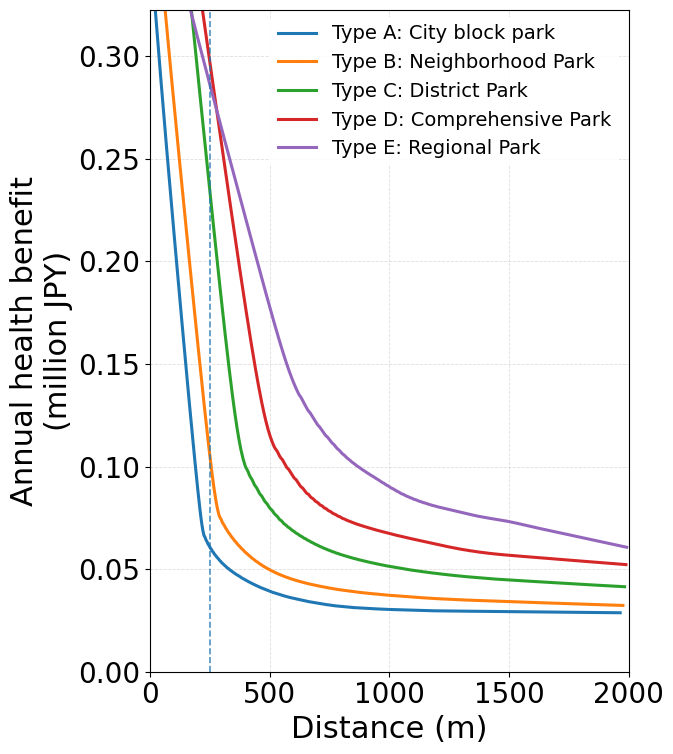

Saved figure: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/src/fig1_loess_x0_vline250_money_millionJPY_by_type_no_overall.png


In [28]:
import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ================== 1) 路径与列名 ==================
file0 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class_shp_filtered.csv"
file1 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class_shp_filtered.csv"
FILES = [file0, file1]

DIST_COL = "dist_straight_m"
PARK_CLASS_COL = "park_class"
Y_COL = "steps"   # 原始列仍是 steps（不改数据源）

# ================== 2) 抽样参数 ==================
CHUNKSIZE = 300_000
TARGET_SAMPLE = 800_000
SEED = 123

# ================== 3) 图1参数（按你最新要求） ==================
XLINE = 250              # 竖向虚线位置
XMAX_PLOT = 2000         # 图上画 0~2000m（LOESS）
MIN_DIST_CLEAN = 10      # 清洗用：过滤极小距离
Q_BINS_PLOT = 100        # 你要求
LOESS_FRAC = 0.5         # 你要求（更平滑）

# ================== 4) OLS 诊断范围（你要求：6000m 内） ==================
OLS_MAX_DIST = 6000

# ================== 5) steps -> money（million JPY） ==================
JPY_PER_STEP = 0.04
POP_SCALE = 134.38
MONEY_MULT = JPY_PER_STEP * POP_SCALE      # JPY/step
MONEY_UNIT = 1_000_000.0                   # 1e6 JPY = 1 million JPY

# y轴标题（✅两行，避免写不下）
Y_LABEL_2LINE = "Annual health benefit\n(million JPY)"

# 原来 steps 的 y 上限是 60,000；现在按同口径换算成“百万日元”
YMAX_STEPS_PLOT = 60_000
YMAX_PLOT = (YMAX_STEPS_PLOT * MONEY_MULT) / MONEY_UNIT  # million JPY

# ================== 6) 类型名称映射（用于图例与表格） ==================
TYPE_NAME = {
    "A": "City block park",
    "B": "Neighborhood Park",
    "C": "District Park",
    "D": "Comprehensive Park",
    "E": "Regional Park",
}
def type_label(g: str) -> str:
    return f"Type {g}: {TYPE_NAME.get(g, g)}"

# ================== ✅ 字体整体放大（≈2倍） ==================
TEXT_SCALE = 2.0
plt.rcParams.update({
    "font.size":        11 * TEXT_SCALE,
    "axes.labelsize":   11 * TEXT_SCALE,
    "xtick.labelsize":  10 * TEXT_SCALE,
    "ytick.labelsize":  10 * TEXT_SCALE,
    "legend.fontsize":   9 * TEXT_SCALE,
})

# ================== 工具：分块抽样读取 ==================
def stream_sample_df(files, usecols, chunksize=CHUNKSIZE, target_sample=TARGET_SAMPLE, seed=SEED):
    rng = np.random.default_rng(seed)
    parts, kept = [], 0
    for fp in files:
        total_size = os.path.getsize(fp)
        pbar = tqdm(total=total_size, desc=f"Sampling {os.path.basename(fp)}", unit="B", unit_scale=True)
        for chunk in pd.read_csv(fp, usecols=usecols, chunksize=chunksize):
            pbar.update(int(chunk.memory_usage(deep=True).sum()))
            chunk = chunk.dropna(subset=usecols)
            chunk = chunk[(chunk[DIST_COL] > 0) & (chunk[Y_COL] > 0)]
            if len(chunk) == 0:
                continue
            remaining = target_sample - kept
            if remaining <= 0:
                break
            frac = min(1.0, remaining / max(len(chunk), 1))
            take = chunk.sample(frac=frac, random_state=int(rng.integers(0, 1e9))) if frac < 1.0 else chunk
            parts.append(take); kept += len(take)
        pbar.close()
    df = pd.concat(parts, ignore_index=True)
    if len(df) > target_sample:
        df = df.sample(n=target_sample, random_state=seed)
    return df

# ================== 工具：等频分箱（避免断点） ==================
def quantile_binned_median(d, y, q_bins=100):
    d = np.asarray(d, np.float64)
    y = np.asarray(y, np.float64)
    n = len(d)
    if n < max(400, q_bins * 8):
        return None
    qs = np.linspace(0, 1, q_bins + 1)
    edges = np.quantile(d, qs)
    edges = np.unique(edges)
    if len(edges) < 5:
        return None
    bid = np.searchsorted(edges, d, side="right") - 1
    ok = (bid >= 0) & (bid < len(edges) - 1)
    d = d[ok]; y = y[ok]; bid = bid[ok]
    dfb = pd.DataFrame({"bin": bid, "d": d, "y": y})
    agg = dfb.groupby("bin").agg(d_med=("d", "median"), y_med=("y", "median"), n=("y", "size")).reset_index()
    return agg.sort_values("d_med")

# ================== 工具：纯numpy LOESS ==================
def loess_np(x, y, frac=0.5, x_new=None):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    idx = np.argsort(x)
    x = x[idx]; y = y[idx]
    n = len(x)
    if n < 3:
        return x, y
    span = int(np.ceil(frac * n))
    span = max(3, min(span, n))
    if x_new is None:
        x_new = np.linspace(x.min(), x.max(), 450)
    else:
        x_new = np.asarray(x_new, dtype=np.float64)
    y_new = np.empty_like(x_new)

    for i, xi in enumerate(x_new):
        dist = np.abs(x - xi)
        nn_idx = np.argpartition(dist, span - 1)[:span]
        xk = x[nn_idx]; yk = y[nn_idx]; dk = dist[nn_idx]
        dmax = dk.max()
        if dmax <= 0:
            y_new[i] = yk.mean()
            continue
        u = dk / dmax
        w = (1 - u**3)**3
        X = np.column_stack([np.ones_like(xk), xk - xi])
        XtW = X.T * w
        A = XtW @ X
        b = XtW @ yk
        A[0, 0] += 1e-12
        A[1, 1] += 1e-12
        beta = np.linalg.solve(A, b)
        y_new[i] = beta[0]
    return x_new, y_new

# ================== 工具：log-log OLS（返回 alpha=logeσ, beta, r2） ==================
def ols_loglog(x, y):
    x = np.asarray(x, np.float64)
    y = np.asarray(y, np.float64)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]; y = y[m]
    if x.size < 5:
        return np.nan, np.nan, np.nan

    lx = np.log(x); ly = np.log(y)
    n = lx.size
    sx = lx.sum(); sy = ly.sum()
    sxx = (lx * lx).sum()
    sxy = (lx * ly).sum()

    denom = (n * sxx - sx * sx)
    if denom == 0:
        return np.nan, np.nan, np.nan

    beta = (n * sxy - sx * sy) / denom
    alpha = (sy - beta * sx) / n

    yhat = alpha + beta * lx
    ss_res = ((ly - yhat) ** 2).sum()
    ss_tot = ((ly - ly.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return float(alpha), float(beta), float(r2)

# ================== 读数据（抽样） ==================
usecols = [DIST_COL, PARK_CLASS_COL, Y_COL]
df = stream_sample_df(FILES, usecols=usecols)

df = df.dropna(subset=usecols).copy()
df = df[(df[DIST_COL] >= MIN_DIST_CLEAN) & (df[Y_COL] > 0)]
df[PARK_CLASS_COL] = df[PARK_CLASS_COL].astype(str).str.strip()

# steps -> money (million JPY)
df["money_mjpy"] = (df[Y_COL].astype(float) * MONEY_MULT) / MONEY_UNIT

print("Sample N:", len(df))
print("park_class unique:", df[PARK_CLASS_COL].nunique())

preferred = ["A", "B", "C", "D", "E"]
present = [c for c in preferred if c in set(df[PARK_CLASS_COL].unique())]
groups = present  # ✅ 不要 Overall
print("Using groups (no Overall):", groups)

# ================== 先输出：每类在 6000m 内的 log-log OLS 诊断参数 ==================
rows = []
for g in groups:
    sub = df[df[PARK_CLASS_COL] == g]
    sub_fit = sub[(sub[DIST_COL] > 0) & (sub[DIST_COL] <= OLS_MAX_DIST) & (sub["money_mjpy"] > 0)]
    n_fit = len(sub_fit)

    alpha, beta, r2 = ols_loglog(sub_fit[DIST_COL].to_numpy(), sub_fit["money_mjpy"].to_numpy())
    rows.append({
        "Type": g,
        "Park type name": TYPE_NAME.get(g, ""),
        "N (dist<=6000m)": n_fit,
        "logeσ": alpha,
        "β": beta,
        "r2 (log)": r2
    })

diag = pd.DataFrame(rows)
diag["Type"] = pd.Categorical(diag["Type"], categories=preferred, ordered=True)
diag = diag.sort_values("Type")

print("\n=== Log-log OLS diagnosis (records within 6000m; y=annual health benefit in million JPY) ===")
print(diag.to_string(index=False, justify="left",
                     formatters={
                         "logeσ": lambda v: f"{v:.6f}" if np.isfinite(v) else "nan",
                         "β":     lambda v: f"{v:.6f}" if np.isfinite(v) else "nan",
                         "r2 (log)": lambda v: f"{v:.4f}" if np.isfinite(v) else "nan",
                     }))

out_diag = "ols_diagnosis_within_6000m_by_type_millionJPY.csv"
diag.to_csv(out_diag, index=False, encoding="utf-8-sig")
print("\nSaved diagnosis table:", os.path.abspath(out_diag))

# ================== 图1：LOESS经验曲线（x从0开始 + x=250竖虚线） ==================
# ✅ 宽高比≈0.9:1（更竖），并保持图例右上布局
fig, ax = plt.subplots(figsize=(7.2, 8.0))

# ✅ 线宽（你要更细就改这里两处）
LW_MAIN  = 2.2
LW_VLINE = 1.2

for g in groups:
    sub = df[df[PARK_CLASS_COL] == g]
    d = sub[DIST_COL].to_numpy()
    y = sub["money_mjpy"].to_numpy()

    # 图1只看 10~2000m（x轴仍从0开始显示）
    m = (d <= XMAX_PLOT)
    d = d[m]; y = y[m]
    if len(d) < 2000:
        continue

    agg = quantile_binned_median(d, y, q_bins=Q_BINS_PLOT)
    if agg is None or len(agg) < 12:
        continue

    x_med = agg["d_med"].to_numpy(np.float64)
    y_med = agg["y_med"].to_numpy(np.float64)

    xl, yl = loess_np(x_med, y_med, frac=LOESS_FRAC)
    ax.plot(xl, yl, linewidth=LW_MAIN, label=type_label(g))

# 竖向虚线：x=250（位置不变）
ax.axvline(XLINE, linestyle="--", linewidth=LW_VLINE, alpha=0.8)

ax.set_xlabel("Distance (m)")
ax.set_ylabel(Y_LABEL_2LINE)   # ✅两行 y 轴标题
ax.set_xlim(0, XMAX_PLOT)
ax.set_ylim(0, YMAX_PLOT)

ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)

fmt = ScalarFormatter(useOffset=False)
fmt.set_scientific(False)
ax.yaxis.set_major_formatter(fmt)
ax.get_yaxis().get_offset_text().set_visible(False)

leg = ax.legend(
    loc="upper right",
    bbox_to_anchor=(0.98, 0.99),   # 右移
    fontsize=14,                   # 稍微小一点
    frameon=True, framealpha=0.90,
    borderaxespad=0.0
)
leg.get_frame().set_edgecolor("none")

# ✅ 不要整体图名（删掉 set_title）
# ax.set_title(...)

plt.tight_layout()
out1 = "fig1_loess_x0_vline250_money_millionJPY_by_type_no_overall.png"
plt.savefig(out1, dpi=260, bbox_inches="tight")
plt.show()
print("Saved figure:", os.path.abspath(out1))


Sampling data_0_with_park_class_shp_filtered.csv:  39%|███▊      | 66.4M/172M [00:00<00:01, 81.0MB/s]
Sampling data_1_with_park_class_shp_filtered.csv:  13%|█▎        | 22.2M/172M [00:00<00:01, 81.2MB/s]


Sample N: 800000
park_class unique: 5
Using groups (no Overall): ['A', 'B', 'C', 'D', 'E']

=== Log-log OLS diagnosis (records within 6000m; y=annual health benefit in million JPY) ===
Type Park type name      N (dist<=6000m) logeσ     β         r2 (log)
A       City block park  73891           -0.641938 -0.369784 0.1081  
B     Neighborhood Park 211694           -0.377908 -0.383301 0.1031  
C         District Park 158958            0.053623 -0.402209 0.0867  
D    Comprehensive Park 130455           -0.001838 -0.367194 0.0574  
E         Regional Park  54719            0.584021 -0.432155 0.0577  

Saved diagnosis table: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/src/ols_diagnosis_within_6000m_by_type_millionJPY.csv


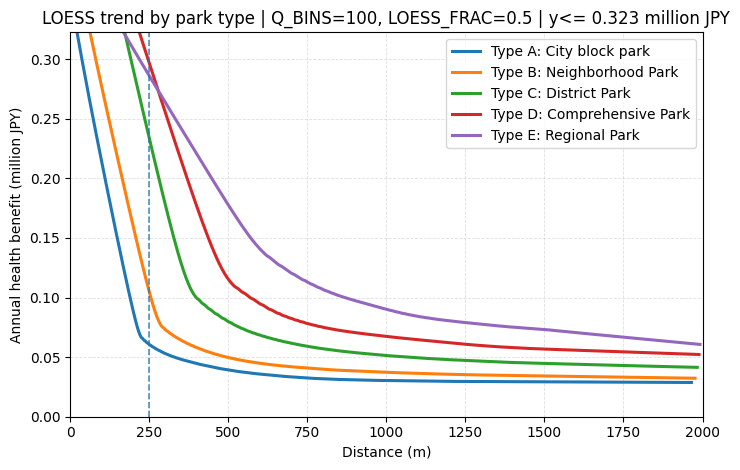

Saved figure: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/src/fig1_loess_x0_vline250_money_millionJPY_by_type_no_overall.png


In [5]:
import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ================== 1) 路径与列名 ==================
file0 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class_shp_filtered.csv"
file1 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class_shp_filtered.csv"
FILES = [file0, file1]

DIST_COL = "dist_straight_m"
PARK_CLASS_COL = "park_class"
Y_COL = "steps"   # 原始列仍是 steps（不改数据源）

# ================== 2) 抽样参数 ==================
CHUNKSIZE = 300_000
TARGET_SAMPLE = 800_000
SEED = 123

# ================== 3) 图1参数（按你最新要求） ==================
XLINE = 250              # 竖向虚线位置
XMAX_PLOT = 2000         # 图上画 0~2000m（LOESS）
MIN_DIST_CLEAN = 10      # 清洗用：过滤极小距离
Q_BINS_PLOT = 100        # 你要求
LOESS_FRAC = 0.5         # 你要求（更平滑）

# ================== 4) OLS 诊断范围（你要求：6000m 内） ==================
OLS_MAX_DIST = 6000

# ================== 5) steps -> money（million JPY） ==================
JPY_PER_STEP = 0.04
POP_SCALE = 134.38
MONEY_MULT = JPY_PER_STEP * POP_SCALE      # JPY/step
MONEY_UNIT = 1_000_000.0                   # 1e6 JPY = 1 million JPY
Y_COL_PLOT = "Annual health benefit (million JPY)"

# 原来 steps 的 y 上限是 60,000；现在按同口径换算成“百万日元”
YMAX_STEPS_PLOT = 60_000
YMAX_PLOT = (YMAX_STEPS_PLOT * MONEY_MULT) / MONEY_UNIT  # million JPY

# ================== 6) 类型名称映射（用于图例与表格） ==================
TYPE_NAME = {
    "A": "City block park",
    "B": "Neighborhood Park",
    "C": "District Park",
    "D": "Comprehensive Park",
    "E": "Regional Park",
}
def type_label(g: str) -> str:
    return f"Type {g}: {TYPE_NAME.get(g, g)}"

# ================== 工具：分块抽样读取 ==================
def stream_sample_df(files, usecols, chunksize=CHUNKSIZE, target_sample=TARGET_SAMPLE, seed=SEED):
    rng = np.random.default_rng(seed)
    parts, kept = [], 0
    for fp in files:
        total_size = os.path.getsize(fp)
        pbar = tqdm(total=total_size, desc=f"Sampling {os.path.basename(fp)}", unit="B", unit_scale=True)
        for chunk in pd.read_csv(fp, usecols=usecols, chunksize=chunksize):
            pbar.update(int(chunk.memory_usage(deep=True).sum()))
            chunk = chunk.dropna(subset=usecols)
            chunk = chunk[(chunk[DIST_COL] > 0) & (chunk[Y_COL] > 0)]
            if len(chunk) == 0:
                continue
            remaining = target_sample - kept
            if remaining <= 0:
                break
            frac = min(1.0, remaining / max(len(chunk), 1))
            take = chunk.sample(frac=frac, random_state=int(rng.integers(0, 1e9))) if frac < 1.0 else chunk
            parts.append(take); kept += len(take)
        pbar.close()
    df = pd.concat(parts, ignore_index=True)
    if len(df) > target_sample:
        df = df.sample(n=target_sample, random_state=seed)
    return df

# ================== 工具：等频分箱（避免断点） ==================
def quantile_binned_median(d, y, q_bins=100):
    d = np.asarray(d, np.float64)
    y = np.asarray(y, np.float64)
    n = len(d)
    if n < max(400, q_bins * 8):
        return None
    qs = np.linspace(0, 1, q_bins + 1)
    edges = np.quantile(d, qs)
    edges = np.unique(edges)
    if len(edges) < 5:
        return None
    bid = np.searchsorted(edges, d, side="right") - 1
    ok = (bid >= 0) & (bid < len(edges) - 1)
    d = d[ok]; y = y[ok]; bid = bid[ok]
    dfb = pd.DataFrame({"bin": bid, "d": d, "y": y})
    agg = dfb.groupby("bin").agg(d_med=("d", "median"), y_med=("y", "median"), n=("y", "size")).reset_index()
    return agg.sort_values("d_med")

# ================== 工具：纯numpy LOESS ==================
def loess_np(x, y, frac=0.5, x_new=None):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    idx = np.argsort(x)
    x = x[idx]; y = y[idx]
    n = len(x)
    if n < 3:
        return x, y
    span = int(np.ceil(frac * n))
    span = max(3, min(span, n))
    if x_new is None:
        x_new = np.linspace(x.min(), x.max(), 450)
    else:
        x_new = np.asarray(x_new, dtype=np.float64)
    y_new = np.empty_like(x_new)

    for i, xi in enumerate(x_new):
        dist = np.abs(x - xi)
        nn_idx = np.argpartition(dist, span - 1)[:span]
        xk = x[nn_idx]; yk = y[nn_idx]; dk = dist[nn_idx]
        dmax = dk.max()
        if dmax <= 0:
            y_new[i] = yk.mean()
            continue
        u = dk / dmax
        w = (1 - u**3)**3
        X = np.column_stack([np.ones_like(xk), xk - xi])
        XtW = X.T * w
        A = XtW @ X
        b = XtW @ yk
        A[0, 0] += 1e-12
        A[1, 1] += 1e-12
        beta = np.linalg.solve(A, b)
        y_new[i] = beta[0]
    return x_new, y_new

# ================== 工具：log-log OLS（返回 alpha=logeσ, beta, r2） ==================
def ols_loglog(x, y):
    x = np.asarray(x, np.float64)
    y = np.asarray(y, np.float64)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]; y = y[m]
    if x.size < 5:
        return np.nan, np.nan, np.nan

    lx = np.log(x); ly = np.log(y)
    n = lx.size
    sx = lx.sum(); sy = ly.sum()
    sxx = (lx * lx).sum()
    sxy = (lx * ly).sum()

    denom = (n * sxx - sx * sx)
    if denom == 0:
        return np.nan, np.nan, np.nan

    beta = (n * sxy - sx * sy) / denom
    alpha = (sy - beta * sx) / n

    yhat = alpha + beta * lx
    ss_res = ((ly - yhat) ** 2).sum()
    ss_tot = ((ly - ly.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return float(alpha), float(beta), float(r2)

# ================== 读数据（抽样） ==================
usecols = [DIST_COL, PARK_CLASS_COL, Y_COL]
df = stream_sample_df(FILES, usecols=usecols)

df = df.dropna(subset=usecols).copy()
df = df[(df[DIST_COL] >= MIN_DIST_CLEAN) & (df[Y_COL] > 0)]
df[PARK_CLASS_COL] = df[PARK_CLASS_COL].astype(str).str.strip()

# steps -> money (million JPY)
df["money_mjpy"] = (df[Y_COL].astype(float) * MONEY_MULT) / MONEY_UNIT

print("Sample N:", len(df))
print("park_class unique:", df[PARK_CLASS_COL].nunique())

preferred = ["A", "B", "C", "D", "E"]
present = [c for c in preferred if c in set(df[PARK_CLASS_COL].unique())]
groups = present  # ✅ 不要 Overall
print("Using groups (no Overall):", groups)

# ================== 先输出：每类在 6000m 内的 log-log OLS 诊断参数 ==================
rows = []
for g in groups:
    sub = df[df[PARK_CLASS_COL] == g]
    sub_fit = sub[(sub[DIST_COL] > 0) & (sub[DIST_COL] <= OLS_MAX_DIST) & (sub["money_mjpy"] > 0)]
    n_fit = len(sub_fit)

    alpha, beta, r2 = ols_loglog(sub_fit[DIST_COL].to_numpy(), sub_fit["money_mjpy"].to_numpy())
    rows.append({
        "Type": g,
        "Park type name": TYPE_NAME.get(g, ""),
        "N (dist<=6000m)": n_fit,
        "logeσ": alpha,
        "β": beta,
        "r2 (log)": r2
    })

diag = pd.DataFrame(rows)
# 排序保持 A-E
diag["Type"] = pd.Categorical(diag["Type"], categories=preferred, ordered=True)
diag = diag.sort_values("Type")

print("\n=== Log-log OLS diagnosis (records within 6000m; y=annual health benefit in million JPY) ===")
print(diag.to_string(index=False, justify="left",
                     formatters={
                         "logeσ": lambda v: f"{v:.6f}" if np.isfinite(v) else "nan",
                         "β":     lambda v: f"{v:.6f}" if np.isfinite(v) else "nan",
                         "r2 (log)": lambda v: f"{v:.4f}" if np.isfinite(v) else "nan",
                     }))

# 可选：保存诊断表
out_diag = "ols_diagnosis_within_6000m_by_type_millionJPY.csv"
diag.to_csv(out_diag, index=False, encoding="utf-8-sig")
print("\nSaved diagnosis table:", os.path.abspath(out_diag))

# ================== 图1：LOESS经验曲线（x从0开始 + x=250竖虚线） ==================
fig, ax = plt.subplots(figsize=(7.4, 4.8))

for g in groups:
    sub = df[df[PARK_CLASS_COL] == g]
    d = sub[DIST_COL].to_numpy()
    y = sub["money_mjpy"].to_numpy()

    # 图1只看 10~2000m（x轴仍从0开始显示）
    m = (d <= XMAX_PLOT)
    d = d[m]; y = y[m]
    if len(d) < 2000:
        continue

    agg = quantile_binned_median(d, y, q_bins=Q_BINS_PLOT)
    if agg is None or len(agg) < 12:
        continue

    x_med = agg["d_med"].to_numpy(np.float64)
    y_med = agg["y_med"].to_numpy(np.float64)

    xl, yl = loess_np(x_med, y_med, frac=LOESS_FRAC)
    ax.plot(xl, yl, linewidth=2.2, label=type_label(g))

# 竖向虚线：x=250
ax.axvline(XLINE, linestyle="--", linewidth=1.2, alpha=0.8)

ax.set_xlabel("Distance (m)")
ax.set_ylabel(Y_COL_PLOT)
ax.set_xlim(0, XMAX_PLOT)
ax.set_ylim(0, YMAX_PLOT)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)

fmt = ScalarFormatter(useOffset=False)
fmt.set_scientific(False)
ax.yaxis.set_major_formatter(fmt)
ax.get_yaxis().get_offset_text().set_visible(False)

ax.legend()
ax.set_title(
    f"LOESS trend by park type | Q_BINS={Q_BINS_PLOT}, LOESS_FRAC={LOESS_FRAC} | y<= {YMAX_PLOT:.3f} million JPY"
)

out1 = "fig1_loess_x0_vline250_money_millionJPY_by_type_no_overall.png"
plt.tight_layout()
plt.savefig(out1, dpi=220)
plt.show()
print("Saved figure:", os.path.abspath(out1))


In [7]:
# ================== OLS diagnosis（按分箱中位数点拟合，r2会显著提高） ==================
OLS_MAX_DIST = 6000
Q_BINS_OLS = 100   # 和你画 LOESS 的 Q_BINS_PLOT 保持一致，便于复现

CATEGORY_NAME = {
    "A": "Block Park",
    "B": "Neighborhood Park",
    "C": "District Park",
    "D": "Comprehensive Park",
    "E": "Regional Park",
}

rows = []
for g in ["A","B","C","D","E"]:
    sub = df[df[PARK_CLASS_COL] == g].copy()
    sub = sub[(sub[DIST_COL] > 0) & (sub[DIST_COL] <= OLS_MAX_DIST) & (sub["money_mjpy"] > 0)]

    # 先分箱取中位数点（关键：旧表很可能是这一口径）
    agg = quantile_binned_median(sub[DIST_COL].to_numpy(), sub["money_mjpy"].to_numpy(), q_bins=Q_BINS_OLS)

    if agg is None or len(agg) < 10:
        alpha = beta = r2 = np.nan
        bins_used = 0
    else:
        alpha, beta, r2 = ols_loglog(agg["d_med"].to_numpy(), agg["y_med"].to_numpy())
        bins_used = len(agg)

    rows.append({
        "Identifier": g,
        "Category": CATEGORY_NAME.get(g, ""),
        "logeσ": alpha,
        "β": beta,
        "r2": r2,
        "bins_used": bins_used,
        "N_records(dist<=6000m)": len(sub),
    })

diag_bin = pd.DataFrame(rows)

print("\n=== Log-log OLS on BINNED MEDIANS (dist<=6000m; y=million JPY) ===")
print(diag_bin.to_string(index=False, justify="left",
                         formatters={
                             "logeσ": lambda v: f"{v:.6f}" if np.isfinite(v) else "nan",
                             "β":     lambda v: f"{v:.6f}" if np.isfinite(v) else "nan",
                             "r2":    lambda v: f"{v:.4f}" if np.isfinite(v) else "nan",
                         }))



=== Log-log OLS on BINNED MEDIANS (dist<=6000m; y=million JPY) ===
Identifier Category           logeσ     β         r2      bins_used  N_records(dist<=6000m)
A                  Block Park -0.376608 -0.416046 0.7026 100         73891                 
B           Neighborhood Park -0.163516 -0.419277 0.7355 100        211694                 
C               District Park  0.187306 -0.421709 0.7417 100        158958                 
D          Comprehensive Park  0.114946 -0.382852 0.7616 100        130455                 
E               Regional Park  0.607459 -0.430835 0.8713 100         54719                 


[INFO] Using columns: ['dist_straight_m', 'steps', 'park_class']
[INFO] groups: ['A', 'B', 'C', 'D', 'E']


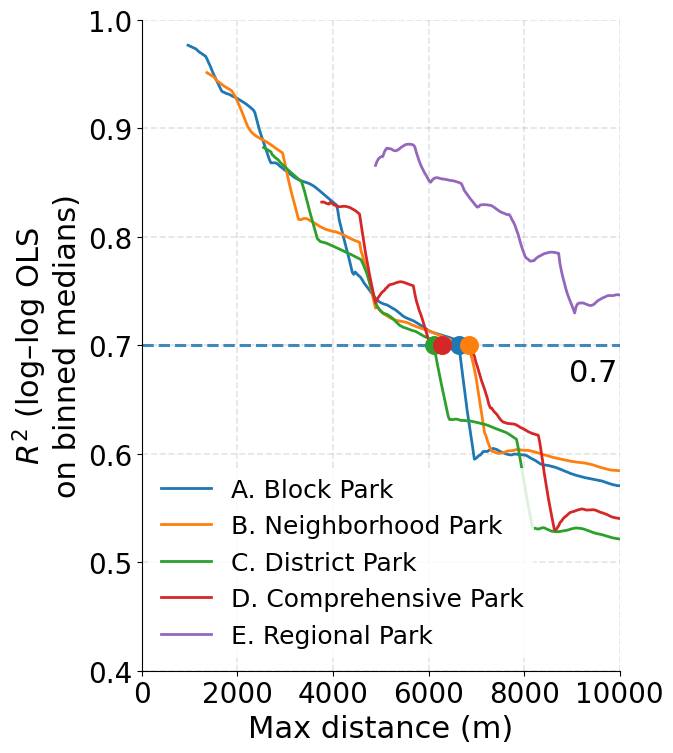

Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/src/fig_r2_vs_dmax_x10000_smooth.png

=== First crossing of R2 threshold (approx., based on smoothed curve) ===
A. Block Park           : ~6,636 m
B. Neighborhood Park    : ~6,840 m
C. District Park        : ~6,112 m
D. Comprehensive Park   : ~6,276 m
E. Regional Park        : (no crossing / insufficient data)


In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) 数据路径（按你之前的）
# =========================
file0 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class_shp_filtered.csv"
file1 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class_shp_filtered.csv"
files = [file0, file1]

# =========================
# 1) 图参数（按你要求）
# =========================
MAX_R2_DIST = 10_000          # ★x轴只画到10000
R2_GRID_N = 320               # 网格密度
Q_BINS_R2 = 10
MIN_BIN_N = 200
MIN_BINS_FOR_FIT = 6
MIN_POINTS_FOR_FIT = 3000
R2_HLINE = 0.7
SMOOTH_WIN = 11
SMOOTH_MIN_VALID = 6

LABEL_MAP = {
    "A": "A. Block Park",
    "B": "B. Neighborhood Park",
    "C": "C. District Park",
    "D": "D. Comprehensive Park",
    "E": "E. Regional Park",
}

# =========================
# 1.1) 字体整体放大（≈2倍）
# =========================
TEXT_SCALE = 2.0
plt.rcParams.update({
    "font.size":        11 * TEXT_SCALE,
    "axes.labelsize":   11 * TEXT_SCALE,
    "xtick.labelsize":  10 * TEXT_SCALE,
    "ytick.labelsize":  10 * TEXT_SCALE,
    "legend.fontsize":   9 * TEXT_SCALE,
})

# =========================
# 2) 自动探测列名 & 读数据
# =========================
def detect_col(cols, candidates):
    lower = {c.lower(): c for c in cols}
    for key in candidates:
        if key.lower() in lower:
            return lower[key.lower()]
    for c in cols:
        cl = c.lower()
        for key in candidates:
            if key.lower() in cl:
                return c
    return None

cols0 = pd.read_csv(files[0], nrows=0).columns.tolist()
DIST_COL = detect_col(cols0, ["dist_straight_m", "dist_m", "distance", "dist"])
Y_COL = detect_col(cols0, ["steps", "step"])
PARK_CLASS_COL = detect_col(cols0, ["park_class", "park_type", "class", "type"])

if DIST_COL is None or Y_COL is None or PARK_CLASS_COL is None:
    raise KeyError(f"识别列名失败：DIST_COL={DIST_COL}, Y_COL={Y_COL}, PARK_CLASS_COL={PARK_CLASS_COL}")

usecols = [DIST_COL, Y_COL, PARK_CLASS_COL]
print("[INFO] Using columns:", usecols)

df = pd.concat(
    [pd.read_csv(fp, usecols=usecols, low_memory=False) for fp in files],
    ignore_index=True
)

df[PARK_CLASS_COL] = df[PARK_CLASS_COL].astype("string").fillna("").str.strip()
if df[PARK_CLASS_COL].str.fullmatch(r"[A-Za-z]").all():
    df[PARK_CLASS_COL] = df[PARK_CLASS_COL].str.upper()

# 只保留 A-E
groups = [g for g in list("ABCDE") if g in set(df[PARK_CLASS_COL].unique())]
print("[INFO] groups:", groups)

# =========================
# 3) 统计/拟合函数
# =========================
def ols_loglog(x, y):
    """log(y)=alpha+beta*log(x)，返回 alpha, beta, r2（log空间）"""
    x = np.asarray(x, np.float64)
    y = np.asarray(y, np.float64)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]; y = y[m]
    if x.size < 5:
        return np.nan, np.nan, np.nan

    lx = np.log(x); ly = np.log(y)
    n = lx.size
    sx = lx.sum(); sy = ly.sum()
    sxx = (lx * lx).sum()
    sxy = (lx * ly).sum()
    den = (n * sxx - sx * sx)
    if den <= 0:
        return np.nan, np.nan, np.nan

    beta = (n * sxy - sx * sy) / den
    alpha = (sy - beta * sx) / n
    yhat = alpha + beta * lx
    ss_res = ((ly - yhat) ** 2).sum()
    ss_tot = ((ly - ly.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return float(alpha), float(beta), float(r2)

def make_fixed_quantile_edges(d, q_bins):
    d = np.asarray(d, np.float64)
    d = d[np.isfinite(d) & (d > 0)]
    if d.size < 1000:
        return None
    edges = np.quantile(d, np.linspace(0, 1, q_bins + 1))
    edges = np.unique(edges)
    if edges.size < 5:
        edges = np.linspace(d.min(), d.max(), q_bins + 1)
    return edges

def binned_median_with_edges(d, y, edges, min_bin_n=MIN_BIN_N):
    d = np.asarray(d, np.float64)
    y = np.asarray(y, np.float64)
    m = np.isfinite(d) & np.isfinite(y) & (d > 0) & (y > 0)
    d = d[m]; y = y[m]
    if d.size == 0:
        return None

    bid = pd.cut(d, bins=edges, include_lowest=True, labels=False)
    tmp = pd.DataFrame({"bin": bid, "d": d, "y": y})
    agg = (tmp.groupby("bin", as_index=False)
              .agg(d_med=("d", "median"), y_med=("y", "median"), n=("y", "size")))
    agg = agg[agg["n"] >= min_bin_n].copy()
    agg = agg.sort_values("d_med")
    return agg if len(agg) else None

def smooth_series_nan(y, win=SMOOTH_WIN, min_valid=SMOOTH_MIN_VALID):
    """中心滚动均值平滑，忽略 NaN；窗口内有效点太少则输出 NaN"""
    s = pd.Series(y, dtype="float64")
    cnt = s.rolling(win, center=True, min_periods=1).count()
    sm = s.rolling(win, center=True, min_periods=1).mean()
    sm[cnt < min_valid] = np.nan
    return sm.to_numpy()

def first_crossing_x(x, y, y0):
    """第一次从 >=y0 跌到 <y0 的交点 x（线性插值），圆点放在 y0 线上"""
    x = np.asarray(x, np.float64)
    y = np.asarray(y, np.float64)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if x.size < 2:
        return np.nan, False
    for i in range(1, x.size):
        if (y[i-1] >= y0) and (y[i] < y0):
            x1, x2 = x[i-1], x[i]
            y1, y2 = y[i-1], y[i]
            if y2 == y1:
                return x2, True
            t = (y0 - y1) / (y2 - y1)
            return x1 + t * (x2 - x1), True
    return np.nan, False

# dmax grid（线性）
dmax_grid = np.linspace(300, MAX_R2_DIST, R2_GRID_N)

# =========================
# 4) 画图
# =========================
# ★宽高比≈0.9:1（竖向更高一些）
fig, ax = plt.subplots(figsize=(7.2, 8.0))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

LW = 1 * TEXT_SCALE
DOT_S = 40 * (TEXT_SCALE ** 2)

cross_summary = []

for g in groups:
    sub = df[df[PARK_CLASS_COL] == g]
    label = LABEL_MAP.get(g, str(g))

    d_all = sub[DIST_COL].to_numpy(np.float64)
    y_all = sub[Y_COL].to_numpy(np.float64)

    m = np.isfinite(d_all) & np.isfinite(y_all) & (d_all > 0) & (y_all > 0)
    d_all = d_all[m]; y_all = y_all[m]

    if d_all.size < MIN_POINTS_FOR_FIT:
        ax.plot(dmax_grid, [np.nan]*len(dmax_grid), lw=LW, label=label)
        cross_summary.append((label, np.nan))
        continue

    order = np.argsort(d_all)
    d_all = d_all[order]
    y_all = y_all[order]

    edges = make_fixed_quantile_edges(d_all[d_all <= MAX_R2_DIST], Q_BINS_R2)
    if edges is None:
        ax.plot(dmax_grid, [np.nan]*len(dmax_grid), lw=LW, label=label)
        cross_summary.append((label, np.nan))
        continue

    r2s = []
    for dm in dmax_grid:
        idx = np.searchsorted(d_all, dm, side="right")
        if idx < MIN_POINTS_FOR_FIT:
            r2s.append(np.nan)
            continue

        agg = binned_median_with_edges(d_all[:idx], y_all[:idx], edges, min_bin_n=MIN_BIN_N)
        if agg is None or len(agg) < MIN_BINS_FOR_FIT:
            r2s.append(np.nan)
            continue

        _, _, r2 = ols_loglog(agg["d_med"].to_numpy(), agg["y_med"].to_numpy())
        r2s.append(r2)

    r2s = np.asarray(r2s, np.float64)
    r2s_sm = smooth_series_nan(r2s, win=SMOOTH_WIN, min_valid=SMOOTH_MIN_VALID)

    ax.plot(dmax_grid, r2s_sm, lw=LW, label=label)

    if R2_HLINE is not None:
        xc, ok = first_crossing_x(dmax_grid, r2s_sm, R2_HLINE)
        if ok:
            ax.scatter([xc], [R2_HLINE], s=DOT_S, zorder=6)
            cross_summary.append((label, xc))
        else:
            cross_summary.append((label, np.nan))

ax.set_xlabel("Max distance (m)")

# ★y轴标题必要时两行（这里直接两行，避免你那种“写不下”问题）
ax.set_ylabel(r"$R^2$ (log–log OLS" + "\n" + r"on binned medians)")

ax.set_xlim(0, MAX_R2_DIST)
ax.set_ylim(0.4, 1.0)

ax.grid(True, linestyle="--", linewidth=0.6 * TEXT_SCALE, alpha=0.35)

# ★0.7 虚线 + 数字标注放在虚线下面
if R2_HLINE is not None:
    ax.axhline(R2_HLINE, linestyle="--", linewidth=1.1 * TEXT_SCALE, alpha=0.85)
    ax.text(
        MAX_R2_DIST * 0.995, R2_HLINE - 0.012, f"{R2_HLINE:.1f}",
        ha="right", va="top"
    )

# ★不要整体图名（不设title）
# ax.set_title(...)

# ★图例：保持你示例那种“左下角贴着”，但字号已随 rcParams 放大
leg = ax.legend(
    loc="lower left",
    bbox_to_anchor=(0.02, 0.02),
    frameon=True,
    framealpha=0.85,
    borderaxespad=0.0,
)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_edgecolor("none")

plt.tight_layout()
out2 = f"fig_r2_vs_dmax_x{MAX_R2_DIST}_smooth.png"
plt.savefig(out2, dpi=260, bbox_inches="tight")
plt.show()

print("Saved:", os.path.abspath(out2))
print("\n=== First crossing of R2 threshold (approx., based on smoothed curve) ===")
for lab, xc in cross_summary:
    if np.isfinite(xc):
        print(f"{lab:24s}: ~{xc:,.0f} m")
    else:
        print(f"{lab:24s}: (no crossing / insufficient data)")


[INFO] Using columns: ['dist_straight_m', 'steps', 'park_class']
[INFO] groups: ['A', 'B', 'C', 'D', 'E']


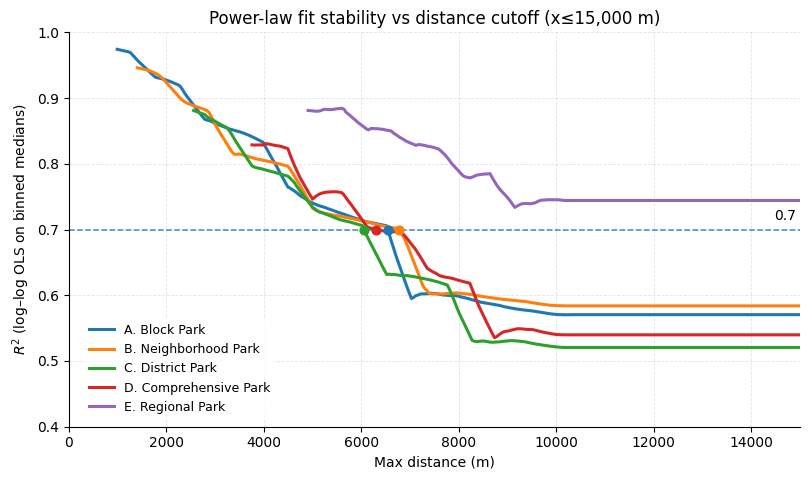

Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/src/fig_r2_vs_dmax_x15000_smooth.png

=== First crossing of R2 threshold (approx., based on smoothed curve) ===
A. Block Park           : ~6,544 m
B. Neighborhood Park    : ~6,767 m
C. District Park        : ~6,051 m
D. Comprehensive Park   : ~6,297 m
E. Regional Park        : (no crossing / insufficient data)


In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) 数据路径（按你之前的）
# =========================
file0 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class_shp_filtered.csv"
file1 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class_shp_filtered.csv"
files = [file0, file1]

# =========================
# 1) 图参数（按你要求）
# =========================
MAX_R2_DIST = 15_000      # ★只画到 15000
R2_GRID_N = 320           # ★加密网格：更平滑（越大越慢）
Q_BINS_R2 = 10
MIN_BIN_N = 200
MIN_BINS_FOR_FIT = 6
MIN_POINTS_FOR_FIT = 3000
R2_HLINE = 0.7

SMOOTH_WIN = 11           # ★滚动平滑窗口（奇数更好：9/11/13）
SMOOTH_MIN_VALID = 6      # 窗口内至少多少个有效点才给平滑值

LABEL_MAP = {
    "A": "A. Block Park",
    "B": "B. Neighborhood Park",
    "C": "C. District Park",
    "D": "D. Comprehensive Park",
    "E": "E. Regional Park",
}

# =========================
# 2) 自动探测列名 & 读数据
# =========================
def detect_col(cols, candidates):
    lower = {c.lower(): c for c in cols}
    for key in candidates:
        if key.lower() in lower:
            return lower[key.lower()]
    for c in cols:
        cl = c.lower()
        for key in candidates:
            if key.lower() in cl:
                return c
    return None

cols0 = pd.read_csv(files[0], nrows=0).columns.tolist()
DIST_COL = detect_col(cols0, ["dist_straight_m", "dist_m", "distance", "dist"])
Y_COL    = detect_col(cols0, ["steps", "step"])
PARK_CLASS_COL = detect_col(cols0, ["park_class", "park_type", "class", "type"])

if DIST_COL is None or Y_COL is None or PARK_CLASS_COL is None:
    raise KeyError(f"识别列名失败：DIST_COL={DIST_COL}, Y_COL={Y_COL}, PARK_CLASS_COL={PARK_CLASS_COL}")

usecols = [DIST_COL, Y_COL, PARK_CLASS_COL]
print("[INFO] Using columns:", usecols)

df = pd.concat([pd.read_csv(fp, usecols=usecols, low_memory=False) for fp in files], ignore_index=True)
df[PARK_CLASS_COL] = df[PARK_CLASS_COL].astype("string").fillna("").str.strip()
if df[PARK_CLASS_COL].str.fullmatch(r"[A-Za-z]").all():
    df[PARK_CLASS_COL] = df[PARK_CLASS_COL].str.upper()

# 只保留 A-E（你不需要 Overall）
groups = [g for g in list("ABCDE") if g in set(df[PARK_CLASS_COL].unique())]
print("[INFO] groups:", groups)

# =========================
# 3) 统计/拟合函数
# =========================
def ols_loglog(x, y):
    """log(y)=alpha+beta*log(x)，返回 alpha, beta, r2（log空间）"""
    x = np.asarray(x, np.float64)
    y = np.asarray(y, np.float64)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]; y = y[m]
    if x.size < 5:
        return np.nan, np.nan, np.nan

    lx = np.log(x); ly = np.log(y)
    n = lx.size
    sx = lx.sum(); sy = ly.sum()
    sxx = (lx * lx).sum()
    sxy = (lx * ly).sum()

    den = (n * sxx - sx * sx)
    if den <= 0:
        return np.nan, np.nan, np.nan

    beta  = (n * sxy - sx * sy) / den
    alpha = (sy - beta * sx) / n

    yhat = alpha + beta * lx
    ss_res = ((ly - yhat) ** 2).sum()
    ss_tot = ((ly - ly.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return float(alpha), float(beta), float(r2)

def make_fixed_quantile_edges(d, q_bins):
    d = np.asarray(d, np.float64)
    d = d[np.isfinite(d) & (d > 0)]
    if d.size < 1000:
        return None
    edges = np.quantile(d, np.linspace(0, 1, q_bins + 1))
    edges = np.unique(edges)
    if edges.size < 5:
        edges = np.linspace(d.min(), d.max(), q_bins + 1)
    return edges

def binned_median_with_edges(d, y, edges, min_bin_n=MIN_BIN_N):
    d = np.asarray(d, np.float64)
    y = np.asarray(y, np.float64)
    m = np.isfinite(d) & np.isfinite(y) & (d > 0) & (y > 0)
    d = d[m]; y = y[m]
    if d.size == 0:
        return None

    bid = pd.cut(d, bins=edges, include_lowest=True, labels=False)
    tmp = pd.DataFrame({"bin": bid, "d": d, "y": y})
    agg = (tmp.groupby("bin", as_index=False)
              .agg(d_med=("d", "median"),
                   y_med=("y", "median"),
                   n=("y", "size")))
    agg = agg[agg["n"] >= min_bin_n].copy()
    agg = agg.sort_values("d_med")
    return agg if len(agg) else None

def smooth_series_nan(y, win=SMOOTH_WIN, min_valid=SMOOTH_MIN_VALID):
    """中心滚动均值平滑，忽略 NaN；窗口内有效点太少则输出 NaN"""
    s = pd.Series(y, dtype="float64")
    cnt = s.rolling(win, center=True, min_periods=1).count()
    sm  = s.rolling(win, center=True, min_periods=1).mean()
    sm[cnt < min_valid] = np.nan
    return sm.to_numpy()

def first_crossing_x(x, y, y0):
    """第一次从 >=y0 跌到 <y0 的交点 x（线性插值），圆点放在 y0 线上"""
    x = np.asarray(x, np.float64)
    y = np.asarray(y, np.float64)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if x.size < 2:
        return np.nan, False
    for i in range(1, x.size):
        if (y[i-1] >= y0) and (y[i] < y0):
            x1, x2 = x[i-1], x[i]
            y1, y2 = y[i-1], y[i]
            if y2 == y1:
                return x2, True
            t = (y0 - y1) / (y2 - y1)
            return x1 + t * (x2 - x1), True
    return np.nan, False

# dmax grid（线性更接近你参考图）
dmax_grid = np.linspace(300, MAX_R2_DIST, R2_GRID_N)

# =========================
# 4) 画图
# =========================
fig, ax = plt.subplots(figsize=(8.2, 4.9))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

LW = 2.2
cross_summary = []

for g in groups:
    sub = df[df[PARK_CLASS_COL] == g]
    label = LABEL_MAP.get(g, str(g))

    d_all = sub[DIST_COL].to_numpy(np.float64)
    y_all = sub[Y_COL].to_numpy(np.float64)

    # 统一清理
    m = np.isfinite(d_all) & np.isfinite(y_all) & (d_all > 0) & (y_all > 0)
    d_all = d_all[m]; y_all = y_all[m]

    if d_all.size < MIN_POINTS_FOR_FIT:
        ax.plot(dmax_grid, [np.nan]*len(dmax_grid), lw=LW, label=label)
        cross_summary.append((label, np.nan))
        continue

    order = np.argsort(d_all)
    d_all = d_all[order]
    y_all = y_all[order]

    # 固定分箱边界（用 d<=MAX_R2_DIST 的数据生成）
    edges = make_fixed_quantile_edges(d_all[d_all <= MAX_R2_DIST], Q_BINS_R2)
    if edges is None:
        ax.plot(dmax_grid, [np.nan]*len(dmax_grid), lw=LW, label=label)
        cross_summary.append((label, np.nan))
        continue

    r2s = []
    for dm in dmax_grid:
        idx = np.searchsorted(d_all, dm, side="right")
        if idx < MIN_POINTS_FOR_FIT:
            r2s.append(np.nan)
            continue

        agg = binned_median_with_edges(d_all[:idx], y_all[:idx], edges, min_bin_n=MIN_BIN_N)
        if agg is None or len(agg) < MIN_BINS_FOR_FIT:
            r2s.append(np.nan)
            continue

        _, _, r2 = ols_loglog(agg["d_med"].to_numpy(), agg["y_med"].to_numpy())
        r2s.append(r2)

    r2s = np.asarray(r2s, np.float64)

    # ★平滑（解决“阶梯感”）
    r2s_sm = smooth_series_nan(r2s, win=SMOOTH_WIN, min_valid=SMOOTH_MIN_VALID)

    ax.plot(dmax_grid, r2s_sm, lw=LW, label=label)

    # 阈值交点（基于平滑曲线找交点）
    if R2_HLINE is not None:
        xc, ok = first_crossing_x(dmax_grid, r2s_sm, R2_HLINE)
        if ok:
            ax.scatter([xc], [R2_HLINE], s=40, zorder=5)
            cross_summary.append((label, xc))
        else:
            cross_summary.append((label, np.nan))

ax.set_xlabel("Max distance (m)")
ax.set_ylabel(r"$R^2$ (log–log OLS on binned medians)")
ax.set_xlim(0, MAX_R2_DIST)
ax.set_ylim(0.4, 1.0)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)

if R2_HLINE is not None:
    ax.axhline(R2_HLINE, linestyle="--", linewidth=1.1, alpha=0.85)
    ax.text(MAX_R2_DIST * 0.995, R2_HLINE + 0.01, f"{R2_HLINE:.1f}",
            ha="right", va="bottom", fontsize=10)

ax.set_title(f"Power-law fit stability vs distance cutoff (x≤{MAX_R2_DIST:,} m)")

# ★图例移到图外，避免和线重合
leg = ax.legend(
    loc="lower left",
    bbox_to_anchor=(0.02, 0.02),   # 轴坐标系(0~1)，越小越靠近原点
    frameon=True,
    framealpha=0.85,
    borderaxespad=0.0,
    fontsize=9
)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_edgecolor("none")


out2 = f"fig_r2_vs_dmax_x{MAX_R2_DIST}_smooth.png"
plt.tight_layout()
plt.savefig(out2, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", os.path.abspath(out2))

print("\n=== First crossing of R2 threshold (approx., based on smoothed curve) ===")
for lab, xc in cross_summary:
    if np.isfinite(xc):
        print(f"{lab:24s}: ~{xc:,.0f} m")
    else:
        print(f"{lab:24s}: (no crossing / insufficient data)")


Sampling data_0_with_park_class_shp_filtered.csv:  39%|███▊      | 66.4M/172M [00:00<00:01, 74.4MB/s]
Sampling data_1_with_park_class_shp_filtered.csv:  13%|█▎        | 22.2M/172M [00:00<00:01, 80.5MB/s]


Sample N: 800000
park_class unique: 5
Using groups: ['A', 'B', 'C', 'D', 'E']


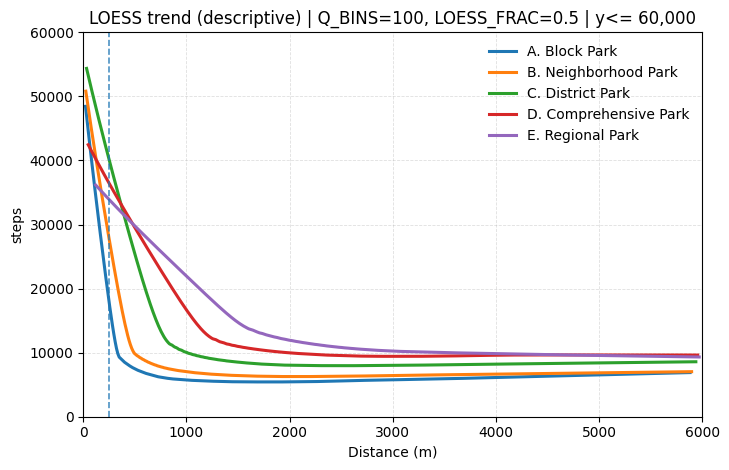

Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/src/fig1_loess_no_overall_labeled.png

=== Power-law parameters (log–log OLS on binned medians, within d<=6000m) ===
A. Block Park            | alpha=ln(sigma)=  11.7571 | sigma=  127657.6 | beta= -0.4160 | R2(log)=0.7026 | bins=100 | N=73,891
B. Neighborhood Park     | alpha=ln(sigma)=  11.9702 | sigma=  157976.1 | beta= -0.4193 | R2(log)=0.7355 | bins=100 | N=211,694
C. District Park         | alpha=ln(sigma)=  12.3210 | sigma=  224363.0 | beta= -0.4217 | R2(log)=0.7417 | bins=100 | N=158,958
D. Comprehensive Park    | alpha=ln(sigma)=  12.2487 | sigma=  208701.6 | beta= -0.3829 | R2(log)=0.7616 | bins=100 | N=130,455
E. Regional Park         | alpha=ln(sigma)=  12.7412 | sigma=  341524.3 | beta= -0.4308 | R2(log)=0.8713 | bins=100 | N=54,719


In [2]:
import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ================== 1) 路径与列名 ==================
file0 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_0_with_park_class_shp_filtered.csv"
file1 = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/6_study_raw_data/data_1_with_park_class_shp_filtered.csv"
FILES = [file0, file1]

DIST_COL = "dist_straight_m"
PARK_CLASS_COL = "park_class"
Y_COL = "steps"

# ================== 2) 抽样参数 ==================
CHUNKSIZE = 300_000
TARGET_SAMPLE = 800_000
SEED = 123

# ================== 3) 图1参数（按你最新要求） ==================
XLINE = 250              # 竖向虚线位置
XMAX_PLOT = 6000
YMAX_PLOT = 60_000

MIN_DIST_CLEAN = 10      # 清洗用：过滤极小距离
Q_BINS_PLOT = 100        # 你要求
LOESS_FRAC = 0.5         # 你要求（更平滑）

# ================== 4) 图例映射（编号+名称） ==================
LABEL_MAP = {
    "A": "A. Block Park",
    "B": "B. Neighborhood Park",
    "C": "C. District Park",
    "D": "D. Comprehensive Park",
    "E": "E. Regional Park",
}

# ================== 工具：分块抽样读取 ==================
def stream_sample_df(files, usecols, chunksize=CHUNKSIZE, target_sample=TARGET_SAMPLE, seed=SEED):
    rng = np.random.default_rng(seed)
    parts, kept = [], 0
    for fp in files:
        total_size = os.path.getsize(fp)
        pbar = tqdm(total=total_size, desc=f"Sampling {os.path.basename(fp)}", unit="B", unit_scale=True)
        for chunk in pd.read_csv(fp, usecols=usecols, chunksize=chunksize):
            pbar.update(int(chunk.memory_usage(deep=True).sum()))
            chunk = chunk.dropna(subset=usecols)
            chunk = chunk[(chunk[DIST_COL] > 0) & (chunk[Y_COL] > 0)]
            if len(chunk) == 0:
                continue
            remaining = target_sample - kept
            if remaining <= 0:
                break
            frac = min(1.0, remaining / max(len(chunk), 1))
            take = chunk.sample(frac=frac, random_state=int(rng.integers(0, 1e9))) if frac < 1.0 else chunk
            parts.append(take); kept += len(take)
        pbar.close()
    df = pd.concat(parts, ignore_index=True)
    if len(df) > target_sample:
        df = df.sample(n=target_sample, random_state=seed)
    return df

# ================== 工具：等频分箱（避免断点） ==================
def quantile_binned_median(d, y, q_bins=100):
    d = np.asarray(d, np.float64)
    y = np.asarray(y, np.float64)
    n = len(d)
    if n < max(400, q_bins * 8):
        return None
    qs = np.linspace(0, 1, q_bins + 1)
    edges = np.quantile(d, qs)
    edges = np.unique(edges)
    if len(edges) < 5:
        return None
    bid = np.searchsorted(edges, d, side="right") - 1
    ok = (bid >= 0) & (bid < len(edges) - 1)
    d = d[ok]; y = y[ok]; bid = bid[ok]
    dfb = pd.DataFrame({"bin": bid, "d": d, "y": y})
    agg = dfb.groupby("bin").agg(d_med=("d", "median"), y_med=("y", "median"), n=("y", "size")).reset_index()
    return agg.sort_values("d_med")

# ================== 工具：纯numpy LOESS ==================
def loess_np(x, y, frac=0.5, x_new=None):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    idx = np.argsort(x)
    x = x[idx]; y = y[idx]
    n = len(x)
    if n < 3:
        return x, y
    span = int(np.ceil(frac * n))
    span = max(3, min(span, n))
    if x_new is None:
        x_new = np.linspace(x.min(), x.max(), 450)
    else:
        x_new = np.asarray(x_new, dtype=np.float64)
    y_new = np.empty_like(x_new)

    for i, xi in enumerate(x_new):
        dist = np.abs(x - xi)
        nn_idx = np.argpartition(dist, span - 1)[:span]
        xk = x[nn_idx]; yk = y[nn_idx]; dk = dist[nn_idx]
        dmax = dk.max()
        if dmax <= 0:
            y_new[i] = yk.mean()
            continue
        u = dk / dmax
        w = (1 - u**3)**3
        X = np.column_stack([np.ones_like(xk), xk - xi])
        XtW = X.T * w
        A = XtW @ X
        b = XtW @ yk
        A[0, 0] += 1e-12
        A[1, 1] += 1e-12
        beta = np.linalg.solve(A, b)
        y_new[i] = beta[0]
    return x_new, y_new

# ================== 工具：log–log OLS（幂律参数） ==================
def ols_loglog(x, y):
    """
    拟合 log(y)=alpha+beta*log(x)
    返回: alpha=ln(sigma), sigma, beta, r2(log)
    """
    x = np.asarray(x, np.float64)
    y = np.asarray(y, np.float64)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]; y = y[m]
    if x.size < 6:
        return np.nan, np.nan, np.nan, np.nan

    lx = np.log(x); ly = np.log(y)
    n = lx.size
    sx = lx.sum(); sy = ly.sum()
    sxx = (lx * lx).sum()
    sxy = (lx * ly).sum()

    den = (n * sxx - sx * sx)
    if den <= 0:
        return np.nan, np.nan, np.nan, np.nan

    beta  = (n * sxy - sx * sy) / den
    alpha = (sy - beta * sx) / n
    sigma = float(np.exp(alpha))

    yhat = alpha + beta * lx
    ss_res = ((ly - yhat) ** 2).sum()
    ss_tot = ((ly - ly.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return float(alpha), float(sigma), float(beta), float(r2)

# ================== 读数据（抽样） ==================
usecols = [DIST_COL, PARK_CLASS_COL, Y_COL]
df = stream_sample_df(FILES, usecols=usecols)

df = df.dropna(subset=usecols).copy()
df = df[(df[DIST_COL] >= MIN_DIST_CLEAN) & (df[Y_COL] > 0)].copy()
df[PARK_CLASS_COL] = df[PARK_CLASS_COL].astype(str).str.strip().str.upper()

print("Sample N:", len(df))
print("park_class unique:", df[PARK_CLASS_COL].nunique())

preferred = ["A", "B", "C", "D", "E"]
present = [c for c in preferred if c in set(df[PARK_CLASS_COL].unique())]
groups = present   # ★不再加 __ALL__/Overall
print("Using groups:", groups)

# ================== 图1：LOESS经验曲线（x从0开始 + x=250竖虚线） ==================
fig, ax = plt.subplots(figsize=(7.4, 4.8))

# 用于打印参数
fit_rows = []

for g in groups:
    sub = df[df[PARK_CLASS_COL] == g]
    d = sub[DIST_COL].to_numpy()
    y = sub[Y_COL].to_numpy()

    # 图1只看 10~2000m（x轴仍从0开始显示）
    m = (d <= XMAX_PLOT)
    d = d[m]; y = y[m]
    if len(d) < 2000:
        continue

    agg = quantile_binned_median(d, y, q_bins=Q_BINS_PLOT)
    if agg is None or len(agg) < 12:
        continue

    x_med = agg["d_med"].to_numpy(np.float64)
    y_med = agg["y_med"].to_numpy(np.float64)

    # LOESS 画线
    xl, yl = loess_np(x_med, y_med, frac=LOESS_FRAC)

    label = LABEL_MAP.get(g, g)
    ax.plot(xl, yl, linewidth=2.2, label=label)

    # 幂律参数：对“同一批分箱中位数点”做 log–log OLS
    alpha, sigma, beta, r2 = ols_loglog(x_med, y_med)
    fit_rows.append((g, label, alpha, sigma, beta, r2, len(agg), len(d)))

# 竖向虚线：x=250
ax.axvline(XLINE, linestyle="--", linewidth=1.2, alpha=0.8)

ax.set_xlabel("Distance (m)")
ax.set_ylabel(Y_COL)
ax.set_xlim(0, XMAX_PLOT)
ax.set_ylim(0, YMAX_PLOT)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)

fmt = ScalarFormatter(useOffset=False); fmt.set_scientific(False)
ax.yaxis.set_major_formatter(fmt)
ax.get_yaxis().get_offset_text().set_visible(False)

ax.legend(frameon=False)
ax.set_title(f"LOESS trend (descriptive) | Q_BINS={Q_BINS_PLOT}, LOESS_FRAC={LOESS_FRAC} | y<= {YMAX_PLOT:,}")

out1 = "fig1_loess_no_overall_labeled.png"
plt.tight_layout()
plt.savefig(out1, dpi=220)
plt.show()
print("Saved:", os.path.abspath(out1))

# ================== 打印每条线的幂律参数（log–log OLS on binned medians） ==================
print("\n=== Power-law parameters (log–log OLS on binned medians, within d<=%dm) ===" % XMAX_PLOT)
for g, label, alpha, sigma, beta, r2, bins_used, n_points in fit_rows:
    print(f"{label:24s} | alpha=ln(sigma)={alpha:9.4f} | sigma={sigma:10.1f} | beta={beta:8.4f} | R2(log)={r2:6.4f} | bins={bins_used:3d} | N={n_points:,}")
